In [1]:
!pip install yfinance

In [2]:
# read files shared via google-drive-link
# https://stackoverflow.com/questions/62759748/downloading-data-from-a-shared-google-drive-link-in-google-colab

!pip uninstall gdown -y && pip install gdown
!gdown -V

Found existing installation: gdown 5.2.0
Uninstalling gdown-5.2.0:
  Successfully uninstalled gdown-5.2.0
gdown 5.2.0 at /usr/local/lib/python3.11/dist-packages


In [3]:
# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import yfinance as yf
import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.graph_objects as go
import plotly.express as px

import time
from datetime import date

# for graphs
import matplotlib.pyplot as plt

# 0) Dataset for Modeling: Final Preparations

## 0.1) Importing data from Drive & defining variable sets
* automated version need to have a daily updated file/database entries

In [4]:
# https://stackoverflow.com/questions/62759748/downloading-data-from-a-shared-google-drive-link-in-google-colab
# truncated data from Module 2: https://drive.google.com/file/d/1mb0ae2M5AouSDlqcUnIwaHq7avwGNrmB/view?usp=sharing
!gdown https://drive.google.com/file/d/1mb0ae2M5AouSDlqcUnIwaHq7avwGNrmB/view?usp=sharing --fuzzy -O /content/

Downloading...
From (original): https://drive.google.com/uc?id=1mb0ae2M5AouSDlqcUnIwaHq7avwGNrmB
From (redirected): https://drive.google.com/uc?id=1mb0ae2M5AouSDlqcUnIwaHq7avwGNrmB&confirm=t&uuid=7be11ab7-0032-4e05-acf8-392ae0f3e48a
To: /content/stocks_df_combined_2025_06_13.parquet.brotli
100% 130M/130M [00:03<00:00, 42.3MB/s]


In [5]:
# truncated
# df = pd.read_parquet("/content/stocks_df_combined_trunc_2014_2023.parquet.brotli", )

# full dataset for 33 stocks
df_full = pd.read_parquet("/content/stocks_df_combined_2025_06_13.parquet.brotli", )

In [6]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 230262 entries, 0 to 5700
Columns: 203 entries, Open to growth_btc_usd_365d
dtypes: datetime64[ns](3), float64(129), int32(64), int64(5), object(2)
memory usage: 302.2+ MB


In [7]:
#df_full.columns

In [8]:
df_full.keys()

Index(['Open', 'High', 'Low', 'Close_x', 'Volume', 'Dividends', 'Stock Splits',
       'Ticker', 'Year', 'Month',
       ...
       'growth_brent_oil_7d', 'growth_brent_oil_30d', 'growth_brent_oil_90d',
       'growth_brent_oil_365d', 'growth_btc_usd_1d', 'growth_btc_usd_3d',
       'growth_btc_usd_7d', 'growth_btc_usd_30d', 'growth_btc_usd_90d',
       'growth_btc_usd_365d'],
      dtype='object', length=203)

In [9]:
# growth indicators (but not future growth)
GROWTH = [g for g in df_full.keys() if (g.find('growth_')==0)&(g.find('future')<0)]
GROWTH

['growth_1d',
 'growth_3d',
 'growth_7d',
 'growth_30d',
 'growth_90d',
 'growth_365d',
 'growth_dax_1d',
 'growth_dax_3d',
 'growth_dax_7d',
 'growth_dax_30d',
 'growth_dax_90d',
 'growth_dax_365d',
 'growth_snp500_1d',
 'growth_snp500_3d',
 'growth_snp500_7d',
 'growth_snp500_30d',
 'growth_snp500_90d',
 'growth_snp500_365d',
 'growth_dji_1d',
 'growth_dji_3d',
 'growth_dji_7d',
 'growth_dji_30d',
 'growth_dji_90d',
 'growth_dji_365d',
 'growth_epi_1d',
 'growth_epi_3d',
 'growth_epi_7d',
 'growth_epi_30d',
 'growth_epi_90d',
 'growth_epi_365d',
 'growth_gold_1d',
 'growth_gold_3d',
 'growth_gold_7d',
 'growth_gold_30d',
 'growth_gold_90d',
 'growth_gold_365d',
 'growth_wti_oil_1d',
 'growth_wti_oil_3d',
 'growth_wti_oil_7d',
 'growth_wti_oil_30d',
 'growth_wti_oil_90d',
 'growth_wti_oil_365d',
 'growth_brent_oil_1d',
 'growth_brent_oil_3d',
 'growth_brent_oil_7d',
 'growth_brent_oil_30d',
 'growth_brent_oil_90d',
 'growth_brent_oil_365d',
 'growth_btc_usd_1d',
 'growth_btc_usd_3d',


In [10]:
# leaving only Volume ==> generate ln(Volume)
OHLCV = ['Open','High','Low','Close','Adj Close_x','Volume']

In [11]:
CATEGORICAL = ['Month', 'Weekday', 'Ticker', 'ticker_type']

In [12]:
TO_PREDICT = [g for g in df_full.keys() if (g.find('future')>=0)]
TO_PREDICT

['growth_future_30d', 'is_positive_growth_30d_future']

In [13]:
TO_DROP = ['Year','Date','index_x', 'index_y', 'index', 'Quarter','Adj Close_y'] + CATEGORICAL + OHLCV
TO_DROP

['Year',
 'Date',
 'index_x',
 'index_y',
 'index',
 'Quarter',
 'Adj Close_y',
 'Month',
 'Weekday',
 'Ticker',
 'ticker_type',
 'Open',
 'High',
 'Low',
 'Close',
 'Adj Close_x',
 'Volume']

In [14]:
# let's define on more custom numerical features
df_full['ln_volume'] = df_full.Volume.apply(lambda x: np.log(x))

/tmp/ipython-input-14-2841410488.py:2: RuntimeWarning: divide by zero encountered in log
  df_full['ln_volume'] = df_full.Volume.apply(lambda x: np.log(x))


In [15]:
#df_full[['SMA10', 'SMA20', 'growing_moving_average', 'high_minus_low_relative','volatility', 'ln_volume']]

In [16]:
# manually defined features
CUSTOM_NUMERICAL = ['SMA10', 'SMA20', 'growing_moving_average', 'high_minus_low_relative','volatility', 'ln_volume']

In [17]:
# All Supported Ta-lib indicators: https://github.com/TA-Lib/ta-lib-python/blob/master/docs/funcs.md

TECHNICAL_INDICATORS = ['adx', 'adxr', 'apo', 'aroon_1','aroon_2', 'aroonosc',
 'bop', 'cci', 'cmo','dx', 'macd', 'macdsignal', 'macdhist', 'macd_ext',
 'macdsignal_ext', 'macdhist_ext', 'macd_fix', 'macdsignal_fix',
 'macdhist_fix', 'mfi', 'minus_di', 'mom', 'plus_di', 'dm', 'ppo',
 'roc', 'rocp', 'rocr', 'rocr100', 'rsi', 'slowk', 'slowd', 'fastk',
 'fastd', 'fastk_rsi', 'fastd_rsi', 'trix', 'ultosc', 'willr',
 'ad', 'adosc', 'obv', 'atr', 'natr', 'ht_dcperiod', 'ht_dcphase',
 'ht_phasor_inphase', 'ht_phasor_quadrature', 'ht_sine_sine', 'ht_sine_leadsine',
 'ht_trendmod', 'avgprice', 'medprice', 'typprice', 'wclprice']

In [18]:
TECHNICAL_PATTERNS = [g for g in df_full.keys() if g.find('cdl')>=0]
print(f'Technical patterns count = {len(TECHNICAL_PATTERNS)}, examples = {TECHNICAL_PATTERNS[0:5]}')


Technical patterns count = 61, examples = ['cdl2crows', 'cdl3blackrows', 'cdl3inside', 'cdl3linestrike', 'cdl3outside']


In [19]:
MACRO = ['gdppot_us_yoy', 'gdppot_us_qoq', 'cpi_core_yoy', 'cpi_core_mom', 'FEDFUNDS',
 'DGS1', 'DGS5', 'DGS10']

In [20]:
NUMERICAL = GROWTH + TECHNICAL_INDICATORS + TECHNICAL_PATTERNS + CUSTOM_NUMERICAL + MACRO

In [21]:
# CHECK: NO OTHER INDICATORS LEFT
OTHER = [k for k in df_full.keys() if k not in OHLCV + CATEGORICAL + NUMERICAL + TO_DROP]
OTHER

['Close_x',
 'Dividends',
 'Stock Splits',
 'growth_future_30d',
 'is_positive_growth_30d_future',
 'Close_y']

In [22]:
df_full.Ticker.nunique()

33

In [23]:
#len(df_full['Ticker'].unique())   same as above code

In [24]:
#pd.DataFrame(df_full['Ticker'].value_counts(), columns=['count'])

In [25]:
#df_full.groupby('Ticker')['Date'].agg(['min','max','count'])  same as below code

In [26]:
# tickers, min-max date, count of daily observations
df_full.groupby(['Ticker'])['Date'].agg(['min','max','count'])

,min,max,count
Ticker,,,
AAPL,1980-12-12,2025-06-13,11217
ACN,2001-07-19,2025-06-13,6012
AMZN,1997-05-15,2025-06-13,7065
ASML,1995-03-15,2025-06-13,7614
AVGO,2009-08-06,2025-06-13,3989
BHARTIARTL.NS,2002-07-01,2025-06-13,5698
BRK-B,1996-05-09,2025-06-13,7322
CDI.PA,1992-01-27,2025-06-13,8610
GOOG,2004-08-19,2025-06-13,5239


In [27]:
# truncated df_full with 25 years of data (and defined growth variables)
df = df_full[df_full.Date>='2000-01-01']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 204 entries, Open to ln_volume
dtypes: datetime64[ns](3), float64(130), int32(64), int64(5), object(2)
memory usage: 253.1+ MB


In [28]:
#df[NUMERICAL]

In [29]:
# let look at the features count and df size:
df[NUMERICAL].info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 184 entries, growth_1d to DGS10
dtypes: float64(121), int32(62), int64(1)
memory usage: 225.3 MB


## 0.2) [Code snippet 1] Generating dummies

In [30]:
# what are the categorical features?
CATEGORICAL

['Month', 'Weekday', 'Ticker', 'ticker_type']

In [31]:
# dummy variables are not generated from Date and numeric variables
df.loc[:,'Month'] = df.Month.dt.strftime('%B')
df.loc[:,'Weekday'] = df.Weekday.astype(str)

/tmp/ipython-input-31-43129475.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['January' 'January' 'January' ... 'June' 'June' 'June']' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.loc[:,'Month'] = df.Month.dt.strftime('%B')
/tmp/ipython-input-31-43129475.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0' '1' '2' ... '2' '3' '4']' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df.loc[:,'Weekday'] = df.Weekday.astype(str)


In [32]:
# df[CATEGORICAL]

### Question 1: Dummies for Month and Week-of-Month

What is the ABSOLUTE CORRELATION VALUE of the most correlated dummy variable _w ```<week_of_month>``` with the binary outcome is_positive_growth_30d_future?

Step 1: Use this [StackOverflow reference](https://stackoverflow.com/questions/25249033/week-of-a-month-pandas) to compute the week of the month using the following formula:
```(d.day - 1) // 7 + 1```

In [33]:
# compute week of month
df.loc[:,'WeekOfMonth'] = (df['Date'].dt.day - 1) // 7 + 1

/tmp/ipython-input-33-4293755155.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'WeekOfMonth'] = (df['Date'].dt.day - 1) // 7 + 1


In [34]:
#df['WeekOfMonth']

Step 2: Create a new string variable that combines the month name and week of the month. Example: 'October_w1', 'November_w2', etc.

In [35]:
# create the combined string column
df.loc[:, 'Month/WeekofMonth'] = df['Month'] + '_w' + df['WeekOfMonth'].astype(str)

/tmp/ipython-input-35-1310019247.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Month/WeekofMonth'] = df['Month'] + '_w' + df['WeekOfMonth'].astype(str)


In [36]:
#df['Month/WeekofMonth']

Step 3: Add the new variable to your set of categorical features.

In [37]:
NEW_CATEGORICAL = CATEGORICAL + ['Month/WeekofMonth']
NEW_CATEGORICAL

['Month', 'Weekday', 'Ticker', 'ticker_type', 'Month/WeekofMonth']

Step 4:
Use pandas.get_dummies() to generate dummy variables for all categorical features.

This should result in approximately 115 dummy variables, including around 60 for the Month/WeekofMonth feature (12 months × up to 5 weeks).

In [38]:
# Generate dummy variables (no need for bool, let's have int32 instead)
dummy_variables = pd.get_dummies(df[NEW_CATEGORICAL], dtype='int32')

In [39]:
dummy_variables.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 115 entries, Month_April to Month/WeekofMonth_September_w5
dtypes: int32(115)
memory usage: 85.6 MB


STep 5: Use DataFrame.corr() to compute the correlation between each feature and the target variable ```is_positive_growth_30d_future.```

In [40]:
#df['is_positive_growth_30d_future']

In [41]:
# Concatenate the dummy variables with the original DataFrame
df_with_dummies = pd.concat([df, dummy_variables], axis=1)

In [42]:
DUMMIES = dummy_variables.keys().to_list()

In [43]:
df_with_dummies[NUMERICAL+DUMMIES].info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 299 entries, growth_1d to Month/WeekofMonth_September_w5
dtypes: float64(121), int32(177), int64(1)
memory usage: 309.5 MB


In [44]:
TO_PREDICT

['growth_future_30d', 'is_positive_growth_30d_future']

In [45]:
# correlation betwen each feature and target variable 'is_positive_growth_30d_future'
corr_is_positive_growth_30d_future = df_with_dummies[NUMERICAL+DUMMIES+TO_PREDICT].corr()['is_positive_growth_30d_future']

In [46]:
#corr_is_positive_growth_30d_future

this can also be used to calcuate the correlation:

- corr_is_positive_growth_30d_future = df_with_dummies[NUMERICAL+DUMMIES+TO_PREDICT].corrwith(df_with_dummies.is_positive_growth_30d_future)

Step 6: Filter the correlation results to include only the dummy variables generated from ```Month/WeekofMonth```

In [47]:
month_week_corr = corr_is_positive_growth_30d_future.filter(like='Month/WeekofMonth_')

In [48]:
#print(month_week_corr)

Step 7: Create a new column named ```abs_corr``` in the correlation results that stores the absolute value of the correlations

In [49]:
month_week_corr = month_week_corr.to_frame(name='corr')

In [50]:
month_week_corr['abs_corr'] = month_week_corr['corr'].abs()

In [51]:
#month_week_corr

Step 8: Sort the correlation results by abs_corr in descending order.

In [52]:
month_week_corr_sorted = month_week_corr.sort_values('abs_corr', ascending=False)

In [53]:
#month_week_corr_sorted

Step 9: Identify and report the highest absolute correlation value among the ```month_week_corr``` dummy variables, rounded to three decimal places.

In [54]:
highest_abs_corr = float(month_week_corr_sorted['abs_corr'].iloc[0].round(3))
print(f"Highest absolute correlation: {highest_abs_corr}")

Highest absolute correlation: 0.025


### Question 2: Define New "Hand" Rules on Macro and Technical Indicator Variables
What is the precision score for the best of the NEW predictions (pred3 or pred4), rounded to 3 digits after the comma?

In this task, you'll apply insights from the visualized decision tree (clf10) (see Code Snippet 5: 1.4.4 Visualisation) to manually define and evaluate new predictive rules.

Step 1: Define two new 'hand' rules based on branches that lead to 'positive' predictions in the tree:

In [55]:
# remove the "segmentation" problem (warning message on df performance after many joins and data transformations)
new_df = df_with_dummies.copy().reset_index(drop=True)

In [56]:
#pred3_manual_dgs10_5 = new_df[(new_df['DGS10'] <= 4.825) & (new_df['DGS5'] <= 0.745)]
#pred4_manual_dgs10_fedfunds = new_df[(new_df['DGS10'] > 4.825) & (new_df['FEDFUNDS'] <= 4.795)]

Step 2: Extend Code Snippet 3 (Manual "hand rule" predictions):

* Implement and apply the above two rules (pred3, pred4) to your dataset.
* Add the resulting predictions as new columns in your dataframe (e.g., new_df).

In [57]:
new_df['pred3_manual_dgs10_5'] = (new_df['DGS10'] <= 4.825) & (new_df['DGS5'] <= 0.745)

In [58]:
new_df['pred4_manual_dgs10_fedfunds'] = (new_df['DGS10'] > 4.825) & (new_df['FEDFUNDS'] <= 4.795)

Step 3: Compute precision:

* For the rule that does make positive predictions on the TEST set, compute its precision score.
* Use standard precision metrics (TP / (TP + FP)).
* Round the precision score to three decimal places.
Example: If your result is 0.57897, your final answer should be: 0.579.

In [59]:
def temporal_split(df, min_date, max_date, train_prop=0.7, val_prop=0.15, test_prop=0.15):
    """
    Splits a DataFrame into three buckets based on the temporal order of the 'Date' column.

    Args:
        df (DataFrame): The DataFrame to split.
        min_date (str or Timestamp): Minimum date in the DataFrame.
        max_date (str or Timestamp): Maximum date in the DataFrame.
        train_prop (float): Proportion of data for training set (default: 0.6).
        val_prop (float): Proportion of data for validation set (default: 0.2).
        test_prop (float): Proportion of data for test set (default: 0.2).

    Returns:
        DataFrame: The input DataFrame with a new column 'split' indicating the split for each row.
    """
    # Define the date intervals
    train_end = min_date + pd.Timedelta(days=(max_date - min_date).days * train_prop)
    val_end = train_end + pd.Timedelta(days=(max_date - min_date).days * val_prop)

    # Assign split labels based on date ranges
    split_labels = []
    for date in df['Date']:
        if date <= train_end:
            split_labels.append('train')
        elif date <= val_end:
            split_labels.append('validation')
        else:
            split_labels.append('test')

    # Add 'split' column to the DataFrame
    df['split'] = split_labels

    return df

In [60]:
new_df['Date'].min(), new_df['Date'].max()

(Timestamp('2000-01-03 00:00:00'), Timestamp('2025-06-13 00:00:00'))

In [61]:
min_date_df = new_df.Date.min()
max_date_df = new_df.Date.max()

new_df = temporal_split(
    df=new_df,
    min_date=min_date_df,
    max_date=max_date_df,
    train_prop=0.7,
    val_prop=0.15,
    test_prop=0.15
)

In [62]:
new_df['split'].value_counts(), len(new_df)

(split
 train         129730
 test           31408
 validation     30657
 Name: count, dtype: int64,
 191795)

In [63]:
new_df['split'].value_counts()/len(new_df)

,count
split,
train,0.676399
test,0.163758
validation,0.159843


In [64]:
new_df.groupby(by='split')['growth_future_30d'].describe()

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,30418.0,1.019899,0.102172,0.580332,0.955986,1.016057,1.077950,1.648934
train,129730.0,1.023864,0.123190,0.246131,0.960248,1.020585,1.083310,5.179689
validation,30657.0,1.029596,0.099908,0.461847,0.973991,1.030784,1.086687,1.783610


In [65]:
# time split on train/validation/test: FIXED dates of split, approx. 70%, 15%, 15% split
new_df.groupby(['split'])['Date'].agg({'min','max','count'})

,count,min,max
split,,,
test,31408,2021-08-20,2025-06-13
train,129730,2000-01-03,2017-10-25
validation,30657,2017-10-26,2021-08-19


In [66]:
# what we try to predict
new_df[TO_PREDICT].head(1)

,growth_future_30d,is_positive_growth_30d_future
0,0.845576,0


In [67]:
# to be used as features
new_df[NUMERICAL+DUMMIES].head(1)

,growth_1d,growth_3d,growth_7d,growth_30d,growth_90d,growth_365d,growth_dax_1d,growth_dax_3d,growth_dax_7d,growth_dax_30d,...,Month/WeekofMonth_October_w1,Month/WeekofMonth_October_w2,Month/WeekofMonth_October_w3,Month/WeekofMonth_October_w4,Month/WeekofMonth_October_w5,Month/WeekofMonth_September_w1,Month/WeekofMonth_September_w2,Month/WeekofMonth_September_w3,Month/WeekofMonth_September_w4,Month/WeekofMonth_September_w5
0,0.998394,0.988341,0.991494,1.372333,1.22295,2.063054,0.970196,0.983855,1.051736,1.134572,...,0,0,0,0,0,0,0,0,0,0


In [68]:
PREDICTIONS = [k for k in new_df.keys() if k.startswith('pred')]
PREDICTIONS

['pred3_manual_dgs10_5', 'pred4_manual_dgs10_fedfunds']

In [69]:
p = PREDICTIONS[0]
part1 = p.split('_')[0] # first prefix before '_'
print(f'Full column name: {p}, only first part: {part1}')

Full column name: pred3_manual_dgs10_5, only first part: pred3


In [70]:
# One prediction: do we predict correctly?
new_df['is_correct_prediction'] = (new_df.pred3_manual_dgs10_5 == new_df.is_positive_growth_30d_future)

In [71]:
new_df[['cci','pred3_manual_dgs10_5','is_positive_growth_30d_future','is_correct_prediction']]

,cci,pred3_manual_dgs10_5,is_positive_growth_30d_future,is_correct_prediction
0,26.847443,False,0,True
1,-34.318580,False,0,True
2,-97.316604,False,0,True
3,-169.947228,False,0,True
4,-142.144015,False,0,True
...,...,...,...,...
191790,144.754024,False,0,True
191791,129.103741,False,0,True
191792,111.169291,False,0,True
191793,-22.369699,False,0,True


In [72]:
# check "Precision" : the percentage of "correct" predictions , WHEN we predict "1" (POSITIVE future growth)
filter = (new_df.split=='test') & (new_df.pred3_manual_dgs10_5==1)
new_df[filter].is_correct_prediction.value_counts()

,count
is_correct_prediction,


In [73]:
new_df[filter].is_correct_prediction.value_counts() / len(new_df[filter])

,count
is_correct_prediction,


In [74]:
#print(filter.sum())

In [75]:
filter = (new_df['split'] == 'test') & (new_df['pred3_manual_dgs10_5'] == 1)

if filter.sum() > 0:
    precision = new_df.loc[filter, 'is_correct_prediction'].mean()
    print(f"Precision on test set: {precision:.2%}")
else:
    print("No positive predictions on the test set for this rule.")

No positive predictions on the test set for this rule.


**Note**: There are no true positives for ```(DGS10 <= 4.825) & (DGS5 <= 0.745); (DGS10 > 4.825) & (FEDFUNDS <= 4.795)``` as seen above.

**Reason**:  Changes in macro conditions/indicators of the time-series data.

In [76]:
# delete this column
del new_df["is_correct_prediction"]

**Updating**:

* pred3_manual_dgs10_5:
(DGS10 <= 4) & (DGS5 <= 1)

* pred4_manual_dgs10_fedfunds:
(DGS10 > 4) & (FEDFUNDS <= 4.795)

In [77]:
new_df['pred3_manual_dgs10_5'] = (new_df['DGS10'] <= 4) & (new_df['DGS5'] <= 1)
new_df['pred4_manual_dgs10_fedfunds'] = (new_df['DGS10'] > 4) & (new_df['FEDFUNDS'] <= 4.795)

In [78]:
new_df['Date'].min(), new_df['Date'].max()

(Timestamp('2000-01-03 00:00:00'), Timestamp('2025-06-13 00:00:00'))

In [79]:
min_date_df = new_df.Date.min()
max_date_df = new_df.Date.max()

new_df = temporal_split(
    df=new_df,
    min_date=min_date_df,
    max_date=max_date_df,
    train_prop=0.7,
    val_prop=0.15,
    test_prop=0.15
)

In [80]:
new_df['split'].value_counts()/len(new_df)

,count
split,
train,0.676399
test,0.163758
validation,0.159843


In [81]:
new_df.groupby(by='split')['growth_future_30d'].describe()

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,30418.0,1.019899,0.102172,0.580332,0.955986,1.016057,1.077950,1.648934
train,129730.0,1.023864,0.123190,0.246131,0.960248,1.020585,1.083310,5.179689
validation,30657.0,1.029596,0.099908,0.461847,0.973991,1.030784,1.086687,1.783610


In [82]:
# time split on train/validation/test: FIXED dates of split, approx. 70%, 15%, 15% split
new_df.groupby(['split'])['Date'].agg({'min','max','count'})

,count,min,max
split,,,
test,31408,2021-08-20,2025-06-13
train,129730,2000-01-03,2017-10-25
validation,30657,2017-10-26,2021-08-19


In [83]:
# what we try to predict
new_df[TO_PREDICT].head(1)

,growth_future_30d,is_positive_growth_30d_future
0,0.845576,0


In [84]:
# to be used as features
new_df[NUMERICAL+DUMMIES].head(1)

,growth_1d,growth_3d,growth_7d,growth_30d,growth_90d,growth_365d,growth_dax_1d,growth_dax_3d,growth_dax_7d,growth_dax_30d,...,Month/WeekofMonth_October_w1,Month/WeekofMonth_October_w2,Month/WeekofMonth_October_w3,Month/WeekofMonth_October_w4,Month/WeekofMonth_October_w5,Month/WeekofMonth_September_w1,Month/WeekofMonth_September_w2,Month/WeekofMonth_September_w3,Month/WeekofMonth_September_w4,Month/WeekofMonth_September_w5
0,0.998394,0.988341,0.991494,1.372333,1.22295,2.063054,0.970196,0.983855,1.051736,1.134572,...,0,0,0,0,0,0,0,0,0,0


In [85]:
PREDICTIONS = [k for k in new_df.keys() if k.startswith('pred')]
PREDICTIONS

['pred3_manual_dgs10_5', 'pred4_manual_dgs10_fedfunds']

In [86]:
p = PREDICTIONS[0]
part1 = p.split('_')[0] # first prefix before '_'
print(f'Full column name: {p}, only first part: {part1}')

Full column name: pred3_manual_dgs10_5, only first part: pred3


In [87]:
# One prediction: do we predict correctly?
new_df['is_correct_prediction'] = (new_df.pred3_manual_dgs10_5 == new_df.is_positive_growth_30d_future)

In [88]:
new_df[['cci','pred3_manual_dgs10_5','is_positive_growth_30d_future','is_correct_prediction']]

,cci,pred3_manual_dgs10_5,is_positive_growth_30d_future,is_correct_prediction
0,26.847443,False,0,True
1,-34.318580,False,0,True
2,-97.316604,False,0,True
3,-169.947228,False,0,True
4,-142.144015,False,0,True
...,...,...,...,...
191790,144.754024,False,0,True
191791,129.103741,False,0,True
191792,111.169291,False,0,True
191793,-22.369699,False,0,True


In [89]:
# check "Precision" : the percentage of "correct" predictions , WHEN we predict "1" (POSITIVE future growth)
filter = (new_df.split=='test') & (new_df.pred3_manual_dgs10_5==1)
new_df[filter].is_correct_prediction.value_counts()

,count
is_correct_prediction,
True,578
False,419


In [90]:
new_df[filter].is_correct_prediction.value_counts() / len(new_df[filter])

,count
is_correct_prediction,
True,0.579739
False,0.420261


In [91]:
precision_true = (new_df[filter].is_correct_prediction.value_counts() / len(new_df[filter])).loc[True]
print(f'True Precision on test set: {round(precision_true,3)}')

True Precision on test set: 0.58


In [92]:
# delete this column
del new_df["is_correct_prediction"]

In [93]:
# generate columns is_correct_
for pred in PREDICTIONS:
  part1 = pred.split('_')[0] # first prefix before '_'
  new_df[f'is_correct_{part1}'] =  (new_df[pred] == new_df.is_positive_growth_30d_future).astype(int)

In [94]:
# IS_CORRECT dataset
IS_CORRECT =  [k for k in new_df.keys() if k.startswith('is_correct_')]
IS_CORRECT

['is_correct_pred3', 'is_correct_pred4']

In [95]:
# sample of a dataframe
new_df[PREDICTIONS+IS_CORRECT+['is_positive_growth_30d_future']].sample(5)

,pred3_manual_dgs10_5,pred4_manual_dgs10_fedfunds,is_correct_pred3,is_correct_pred4,is_positive_growth_30d_future
180266,False,True,0,1,1
17907,False,True,0,1,1
75645,False,True,1,0,0
6428,False,False,0,0,1
46382,False,False,0,0,1


In [96]:
len(new_df[new_df.split=='test'])

31408

In [97]:
# define "Precision" for ALL predictions on a Test dataset (~4 last years of trading)
for i,column in enumerate(IS_CORRECT):
  prediction_column = PREDICTIONS[i]
  is_correct_column = column
  filter = (new_df.split=='test') & (new_df[prediction_column]==1)
  print(f'Prediction column:{prediction_column} , is_correct_column: {is_correct_column}')
  print(new_df[filter][is_correct_column].value_counts())
  print(new_df[filter][is_correct_column].value_counts()/len(new_df[filter]))

  print('---------')


# Note: this code here gave no hand-rule precision.

Prediction column:pred3_manual_dgs10_5 , is_correct_column: is_correct_pred3
is_correct_pred3
1    578
0    419
Name: count, dtype: int64
is_correct_pred3
1    0.579739
0    0.420261
Name: count, dtype: float64
---------
Prediction column:pred4_manual_dgs10_fedfunds , is_correct_column: is_correct_pred4
is_correct_pred4
0    3020
1    2640
Name: count, dtype: int64
is_correct_pred4
0    0.533569
1    0.466431
Name: count, dtype: float64
---------


### Question 3: Unique Correct Predictions from a 10-Level Decision Tree Classifier (pred5_clf_10)
**What is the total number of records in the TEST dataset where the new prediction pred5_clf_10 is correct, while all 'hand' rule predictions (pred0 to pred4) are incorrect?**

To ensure reproducibility, please include the following parameter in the Decision Tree Classifier:

```clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)```

Step 1: Train the Decision Tree and Generate Predictions
* wrangle and split data into TRAIN, VALIDATION AND TEST sets

In [98]:
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

In [99]:
# Decision Tree doesn't like too large and inf. values
import numpy as np

def remove_infinite_values(X):
    """
    Remove infinite values from the input array.

    Parameters:
    - X: Input array (NumPy array or array-like)

    Returns:
    - Array with infinite values removed
    """
    return X[np.isfinite(X).all(axis=1)]

# Example usage:
# Assuming X is your input data
# filtered_X = remove_infinite_values(X)

In [100]:
# look carefully for 'count' to be close to total values (or you need to replace NaNs/remove NaNs), and min/max doesn't equal to -+inf.
#  it will give you an idea to dig deeper into some features to understand the 'nature' of a problem
pd.set_option('display.max_rows', None)

new_df[NUMERICAL+DUMMIES].describe().T

,count,mean,std,min,25%,50%,75%,max
growth_1d,191780.0,1.000859e+00,2.452123e-02,2.300550e-01,9.906947e-01,1.000476e+00,1.010665e+00,4.374775e+00
growth_3d,191750.0,1.002521e+00,3.993495e-02,2.425170e-01,9.842335e-01,1.002102e+00,1.020130e+00,4.446675e+00
growth_7d,191690.0,1.005780e+00,5.852670e-02,2.326554e-01,9.773162e-01,1.005334e+00,1.033346e+00,4.599882e+00
growth_30d,191345.0,1.024514e+00,1.175381e-01,2.461313e-01,9.617043e-01,1.021615e+00,1.083333e+00,5.179689e+00
growth_90d,190445.0,1.075941e+00,2.187319e-01,1.890118e-01,9.571314e-01,1.060631e+00,1.173104e+00,5.970050e+00
growth_365d,186035.0,1.357578e+00,6.215502e-01,9.783037e-02,1.019063e+00,1.244345e+00,1.533772e+00,9.819904e+00
growth_dax_1d,188637.0,1.000281e+00,1.405046e-02,8.776139e-01,9.939059e-01,1.000773e+00,1.007130e+00,1.114020e+00
growth_dax_3d,188637.0,1.000911e+00,2.396851e-02,8.374862e-01,9.894033e-01,1.002214e+00,1.013910e+00,1.144124e+00
growth_dax_7d,188637.0,1.002258e+00,3.562933e-02,7.318924e-01,9.850482e-01,1.004862e+00,1.021715e+00,1.232460e+00
growth_dax_30d,188637.0,1.009702e+00,7.119843e-02,6.263172e-01,9.743297e-01,1.015596e+00,1.051303e+00,1.288371e+00


In [101]:
# Split the data into training and testing sets based on the split date
features_list = NUMERICAL+DUMMIES
to_predict = 'is_positive_growth_30d_future'

train_df = new_df[new_df.split.isin(['train','validation'])].copy(deep=True)
test_df = new_df[new_df.split.isin(['test'])].copy(deep=True)

# ONLY numerical Separate features and target variable for training and testing sets
# need Date and Ticker later when merging predictions to the dataset
X_train = train_df[features_list+[to_predict,'Date','Ticker']]
X_test = test_df[features_list+[to_predict,'Date','Ticker']]

print(f'length: X_train {X_train.shape},  X_test {X_test.shape}')

length: X_train (160387, 302),  X_test (31408, 302)


In [102]:
# All data to be used in predicitons
all_df = new_df[new_df.split.isin(['train','validation','test'])].copy(deep=True)

X_all = all_df[features_list+[to_predict,'Date','Ticker']]

print(f'length: X_all {X_all.shape}')

length: X_all (191795, 302)


In [103]:
from re import X
# Can't have +-inf values . E.g. ln(volume)=-inf when volume==0 => substitute with 0

# Disable SettingWithCopyWarning
pd.options.mode.chained_assignment = None  # default='warn'

X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
X_all.replace([np.inf, -np.inf], np.nan, inplace=True)

# Need to fill NaNs somehow
X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)
X_all.fillna(0, inplace=True)

print(f'length: X_train_imputed {X_train.shape},  X_test_imputed {X_test.shape}, X_all_imputed {X_all.shape}')

length: X_train_imputed (160387, 302),  X_test_imputed (31408, 302), X_all_imputed (191795, 302)


In [104]:
# you may want to remove 1-2% outliers based on percentile ==> not used here in Decision Trees
def remove_outliers_percentile(X, lower_percentile=1, upper_percentile=99):
    """
    Remove outliers from the input array based on percentiles.

    Parameters:
    - X: Input array (NumPy array or array-like)
    - lower_percentile: Lower percentile threshold (float, default=1)
    - upper_percentile: Upper percentile threshold (float, default=99)

    Returns:
    - Array with outliers removed
    """
    lower_bound = np.percentile(X, lower_percentile, axis=0)
    upper_bound = np.percentile(X, upper_percentile, axis=0)
    mask = np.logical_and(np.all(X >= lower_bound, axis=1), np.all(X <= upper_bound, axis=1))
    return X[mask]

# Example usage:
# Assuming X is your input data
# filtered_X = remove_outliers_percentile(X, lower_percentile=1, upper_percentile=99)

In [105]:
X_train_imputed = X_train # we won't use outliers removal to save more data to train: remove_outliers_percentile(X_train)
X_test_imputed = X_test # we won't use outliers removal to save more data to test: remove_outliers_percentile(X_test)
X_all_imputed = X_all # we won't use outliers removal to save more data to test: remove_outliers_percentile(X_all)

# same shape
print(f'length: X_train_imputed {X_train_imputed.shape},  X_test_imputed {X_test_imputed.shape}, X_all_imputed {X_all_imputed.shape}')

length: X_train_imputed (160387, 302),  X_test_imputed (31408, 302), X_all_imputed (191795, 302)


In [106]:
y_train = X_train_imputed[to_predict]
y_test = X_test_imputed[to_predict]
y_all = X_all_imputed[to_predict]

# remove y_train, y_test, y_all from X_ dataframes
del X_train_imputed[to_predict]
#del X_test_imputed[to_predict]
del X_all_imputed[to_predict]

* Initialize a Decision Tree Classifier with a maximum depth of 10 and set random_state=42 for reproducibility.
* Fit the classifier on the combined TRAIN and VALIDATION datasets.

In [107]:
# INPUTS:
# X_train_imputed : CLEAN dataFrame with only numerical features (train+validation periods)
# X_test_imputed : CLEAN dataFrame with only numerical features (test periods)

# y_train : true values for the train period
# y_test  : true values for the test period

In [108]:
# estimation/fit function (using dataframe of features X and what to predict y) --> optimising total accuracy
# max_depth is hyperParameter
def fit_decision_tree(X, y, max_depth, random_state=42):
# Initialize the Decision Tree Classifier
  clf = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)

  # Fit the classifier to the training data
  clf.fit(X, y)
  return clf, X.columns

In [109]:
# using max_depth = 10

%%time
clf_10, train_columns = fit_decision_tree(
    X=X_train_imputed.drop(['Date','Ticker'],axis=1),
    y=y_train,
    max_depth=10,
    random_state=42
)

CPU times: user 28.6 s, sys: 302 ms, total: 28.9 s
Wall time: 29.1 s


Inference for a Decision Tree:

* Use the trained model to predict on the entire dataset (TRAIN + VALIDATION + TEST).

In [110]:
def predict_decision_tree(clf: DecisionTreeClassifier, df_X: pd.DataFrame, y_true: pd.Series):
    # Predict the target variable on the input data
    y_pred = clf.predict(df_X)

    max_depth = clf.tree_.max_depth
    print("Maximum depth of the decision tree:", max_depth)

    # Use y_true passed to the function
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    print(f'Accuracy = {accuracy}, precision = {precision}')

    # Combine features, true y, and predictions
    result_df = pd.concat([df_X, y_true, pd.Series(y_pred, index=df_X.index, name='pred_')], axis=1)

    return result_df

In [111]:
pred10 = predict_decision_tree(clf_10, X_all.drop(['Date','Ticker'],axis=1), y_all)

Maximum depth of the decision tree: 10
Accuracy = 0.6958314867436586, precision = 0.6950666328571831


In [112]:
# correct predictions to incorrect predictions
pred10.pred_.value_counts()

,count
pred_,
1,141972
0,49823


* Store these predictions in a new column named ```pred5_clf_10``` within your main dataframe.

In [113]:
pred10_df = pred10[['pred_']].rename(columns={'pred_': 'pred5_clf_10'})
pred10_df.head(1)

,pred5_clf_10
0,0


In [114]:
newdf_pred10 = pred10_df.join(new_df)
newdf_pred10.sample(5)

,pred5_clf_10,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Ticker,Year,...,Month/WeekofMonth_September_w1,Month/WeekofMonth_September_w2,Month/WeekofMonth_September_w3,Month/WeekofMonth_September_w4,Month/WeekofMonth_September_w5,pred3_manual_dgs10_5,pred4_manual_dgs10_fedfunds,split,is_correct_pred3,is_correct_pred4
136059,1,1253.849976,1256.750000,1236.000000,1241.900024,8120332.0,0.0,0.0,RELIANCE.NS,2025,...,0,0,0,0,0,False,True,test,1,0
28002,1,18.030001,18.293501,17.854000,18.105000,77640000.0,0.0,0.0,AMZN,2014,...,0,0,0,0,0,False,False,train,1,1
95249,1,27.200150,27.332119,27.104842,27.244141,834400.0,0.0,0.0,SAP,2004,...,0,0,0,0,0,False,True,train,0,1
149148,1,333.691199,337.199779,313.266243,332.876709,7884465.0,0.0,0.0,BHARTIARTL.NS,2007,...,0,0,0,0,0,False,False,train,0,0
133870,1,209.631839,210.896678,207.718092,209.048920,8349402.0,0.0,0.0,RELIANCE.NS,2016,...,0,0,0,0,0,False,False,train,0,0


Step 2: **Identify Unique Correct Predictions by pred5_clf_10**
* Create a new boolean column, only_pred5_is_correct, that is True only when:
  
  * The prediction from pred5_clf_10 is correct (i.e., matches the true label).
  * All other hand rule predictions (pred0 through pred4) are incorrect.

In [115]:
# Check if pred5_clf_10 is correct
newdf_pred10['pred5_clf10_is_correct'] = (newdf_pred10['pred5_clf_10'] == newdf_pred10['is_positive_growth_30d_future'])

In [116]:
# compare sample of correct predictions
newdf_pred10[['pred5_clf_10', 'is_positive_growth_30d_future', 'pred5_clf10_is_correct']].sample(5)

,pred5_clf_10,is_positive_growth_30d_future,pred5_clf10_is_correct
26437,0,0,True
42681,0,0,True
9576,1,1,True
135555,1,0,False
26409,1,1,True


In [117]:
# Check if each hand rule is incorrect (compared to true label)
hand_preds = ['pred3_manual_dgs10_5', 'pred4_manual_dgs10_fedfunds']
hand_incorrect = (newdf_pred10[hand_preds] != newdf_pred10['is_positive_growth_30d_future'].values[:, None])

# Require ALL to be incorrect
all_hand_incorrect = hand_incorrect.all(axis=1)

In [118]:
#all_hand_incorrect.value_counts()

In [119]:
# Combine with pred5 being correct
newdf_pred10['only_pred5_is_correct'] = newdf_pred10['pred5_clf10_is_correct'] & all_hand_incorrect

# Quick count
print(newdf_pred10['only_pred5_is_correct'].value_counts())

only_pred5_is_correct
False    126254
True      65541
Name: count, dtype: int64


Step 3: **Count Unique Correct Predictions on the TEST Set**
* Convert the only_pred5_is_correct column from boolean to integer.

In [120]:
newdf_pred10['only_pred5_is_correct'] = newdf_pred10['only_pred5_is_correct'].astype(int)

In [121]:
#newdf_pred10['only_pred5_is_correct'].sample(5)

* Filter the dataframe for records belonging to the TEST dataset.

In [122]:
test_df_only = newdf_pred10[newdf_pred10['split'] == 'test'].copy()

* Count how many records in the TEST set have only_pred5_is_correct equal to 1.

In [123]:
count_only_pred5_correct = test_df_only[test_df_only['only_pred5_is_correct'] == 1].shape

In [124]:
count_only_pred5_correct

(9565, 329)


* Report this count as your final answer.

In [125]:
print(f"Number of records in TEST set with only_pred5_is_correct == 1 is {count_only_pred5_correct[0]}")

Number of records in TEST set with only_pred5_is_correct == 1 is 9565


### Question 4: Hyperparameter tuning for a Decision Tree
What is the optimal tree depth (from 1 to 20) for a DecisionTreeClassifier?

NOTE: please include random_state=42 to the Decision Tree Classifier initialization (e.g., clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)) to ensure consistency in results.

**Instructions:**
* Iterate through max_depth values from 1 to 20.
* For each max_depth:
Train a Decision Tree Classifier with the current max_depth on the combined TRAIN+VALIDATION dataset.

In [126]:
def fit_decision_tree(X, y, max_depth, random_state=42):
# Initialize the Decision Tree Classifier
  clf = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)

  # Fit the classifier to the training data
  clf.fit(X, y)
  return clf, X.columns

In [127]:
%%time
clfs = {}
for m in range(1, 21):
    clf, train_columns = fit_decision_tree(
        X=X_train_imputed.drop(['Date','Ticker'], axis=1),
        y=y_train,
        max_depth=m,
        random_state=42
    )
    clfs[m] = clf
    print(f"Trained Decision Tree with max_depth={m}")


Trained Decision Tree with max_depth=1
Trained Decision Tree with max_depth=2
Trained Decision Tree with max_depth=3
Trained Decision Tree with max_depth=4
Trained Decision Tree with max_depth=5
Trained Decision Tree with max_depth=6
Trained Decision Tree with max_depth=7
Trained Decision Tree with max_depth=8
Trained Decision Tree with max_depth=9
Trained Decision Tree with max_depth=10
Trained Decision Tree with max_depth=11
Trained Decision Tree with max_depth=12
Trained Decision Tree with max_depth=13
Trained Decision Tree with max_depth=14
Trained Decision Tree with max_depth=15
Trained Decision Tree with max_depth=16
Trained Decision Tree with max_depth=17
Trained Decision Tree with max_depth=18
Trained Decision Tree with max_depth=19
Trained Decision Tree with max_depth=20
CPU times: user 9min 20s, sys: 3.92 s, total: 9min 24s
Wall time: 9min 28s


Optionally, visualize how the 'head' (top levels) of each fitted tree changes with increasing tree depth. You can use:
* [sklearn.tree.plot_tree()](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html) for graphical visualization

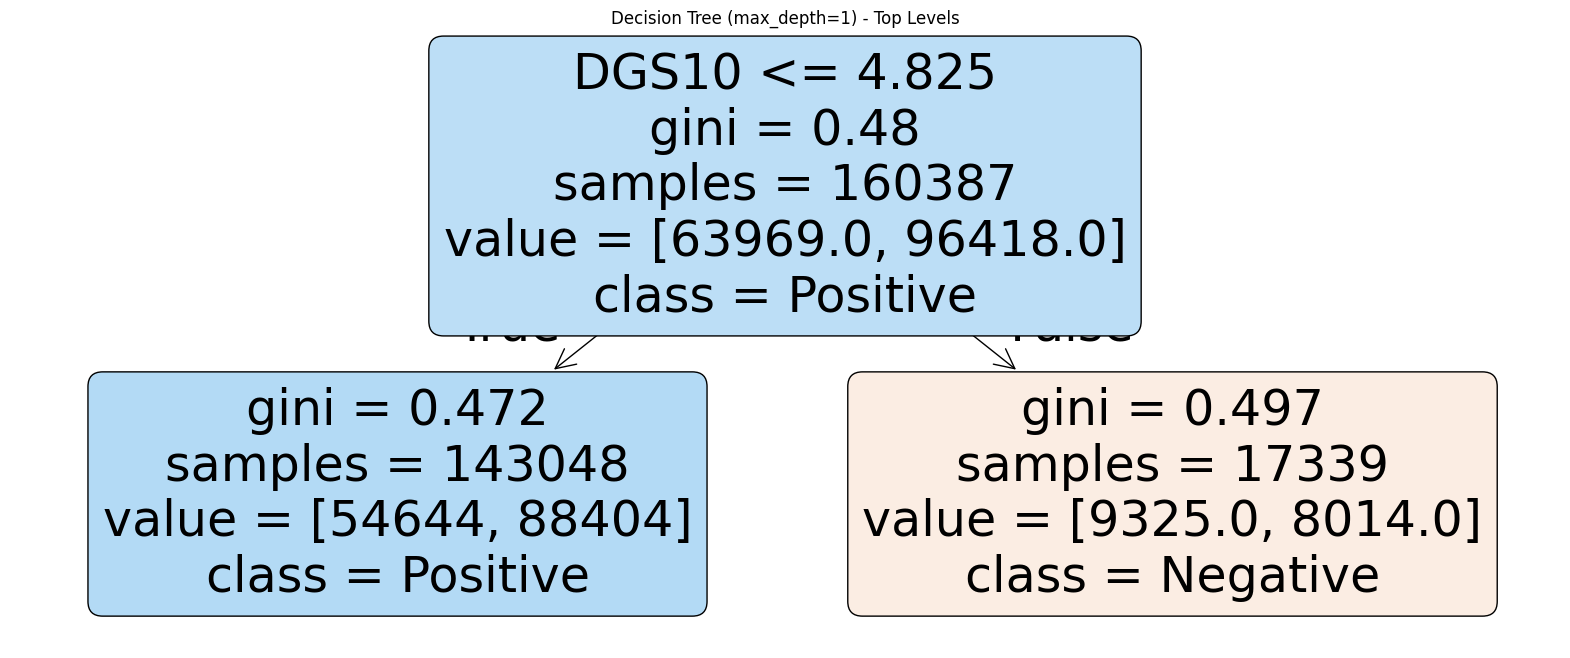

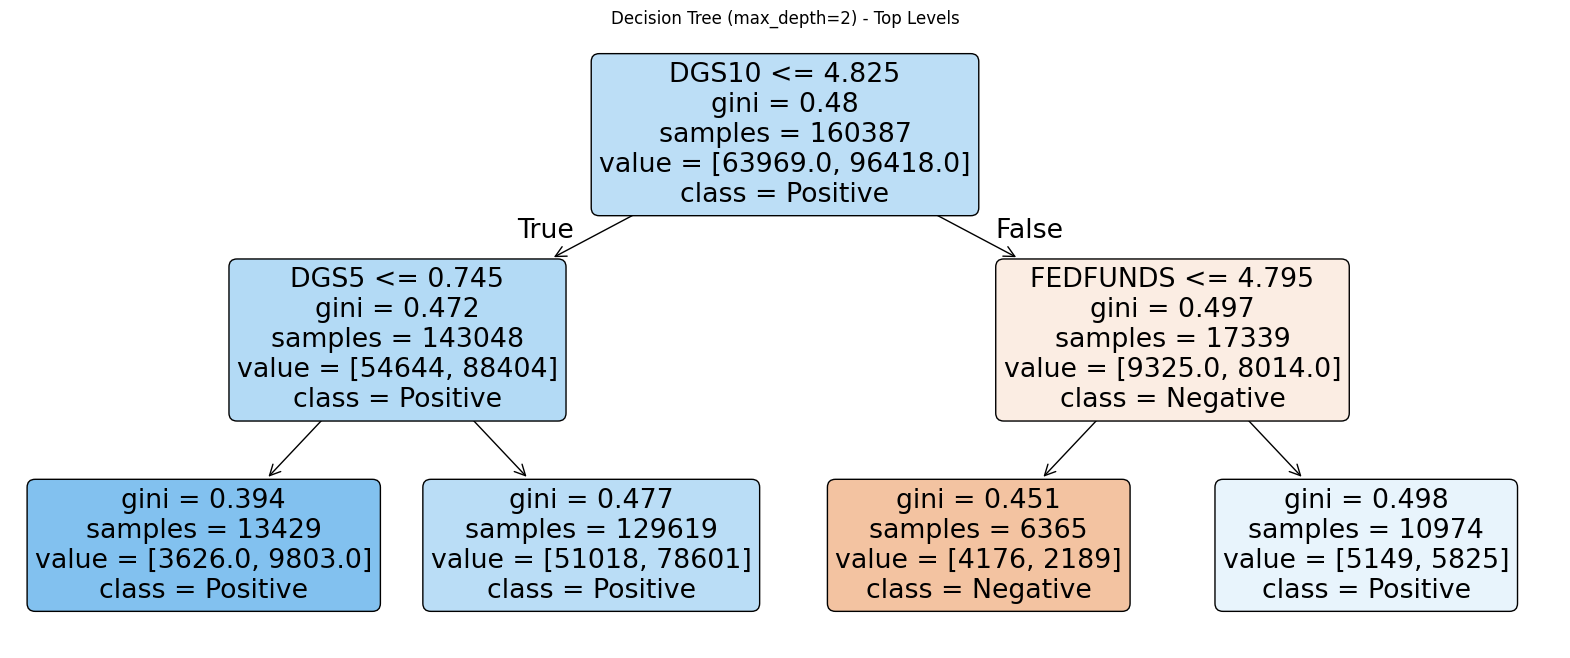

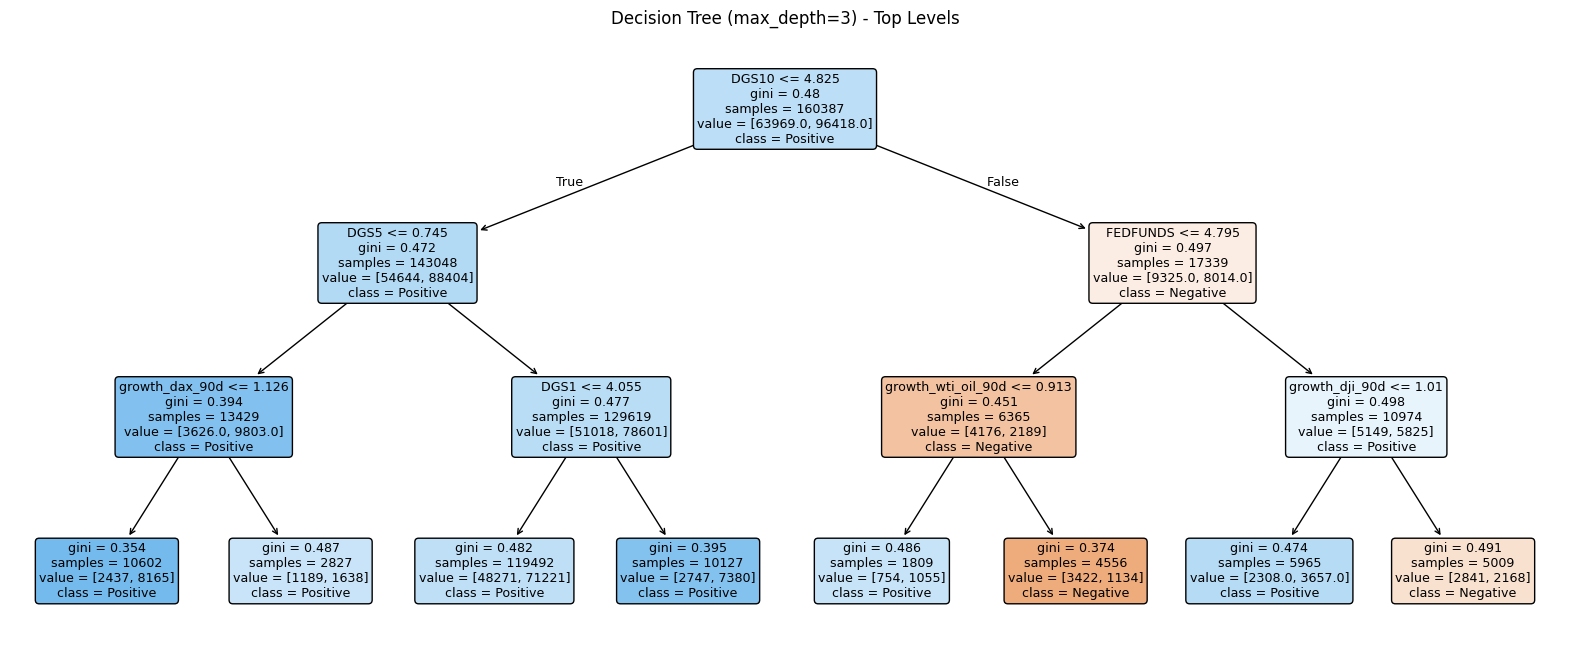

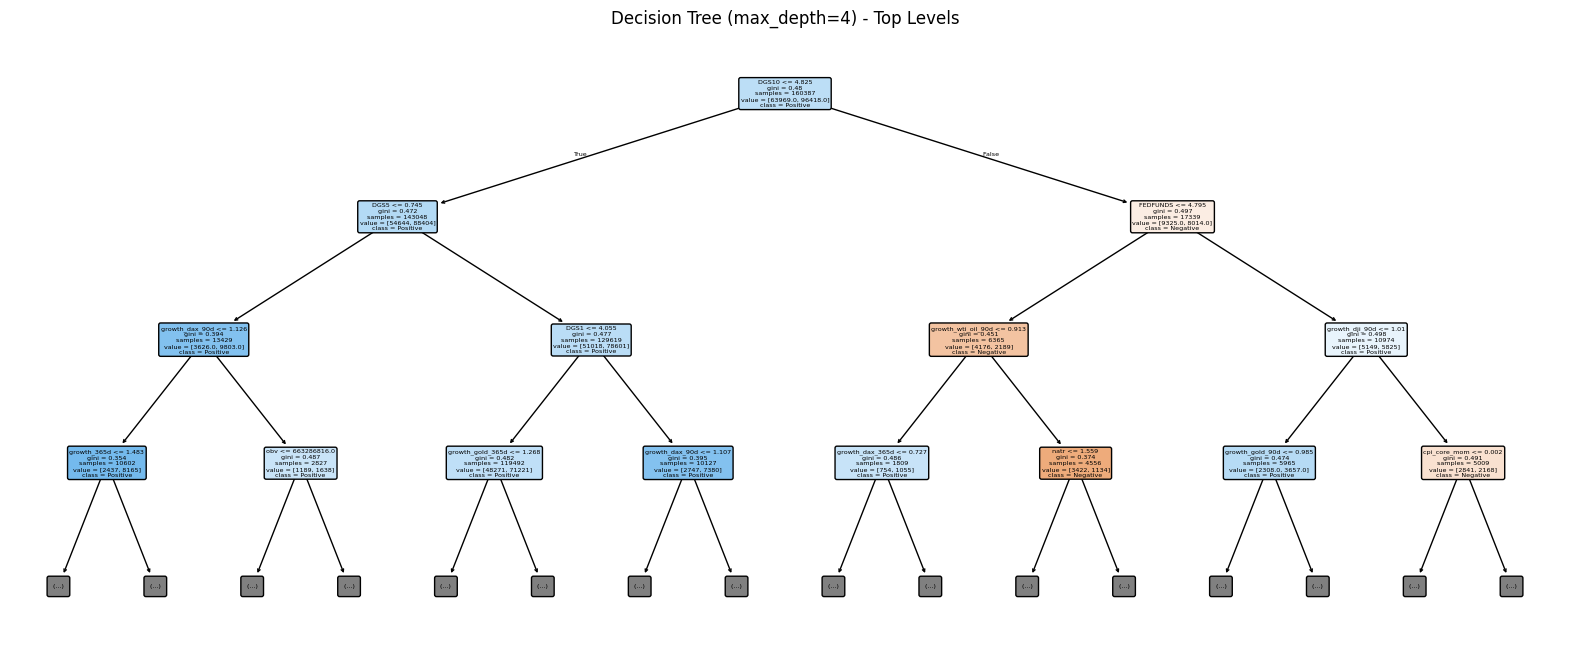

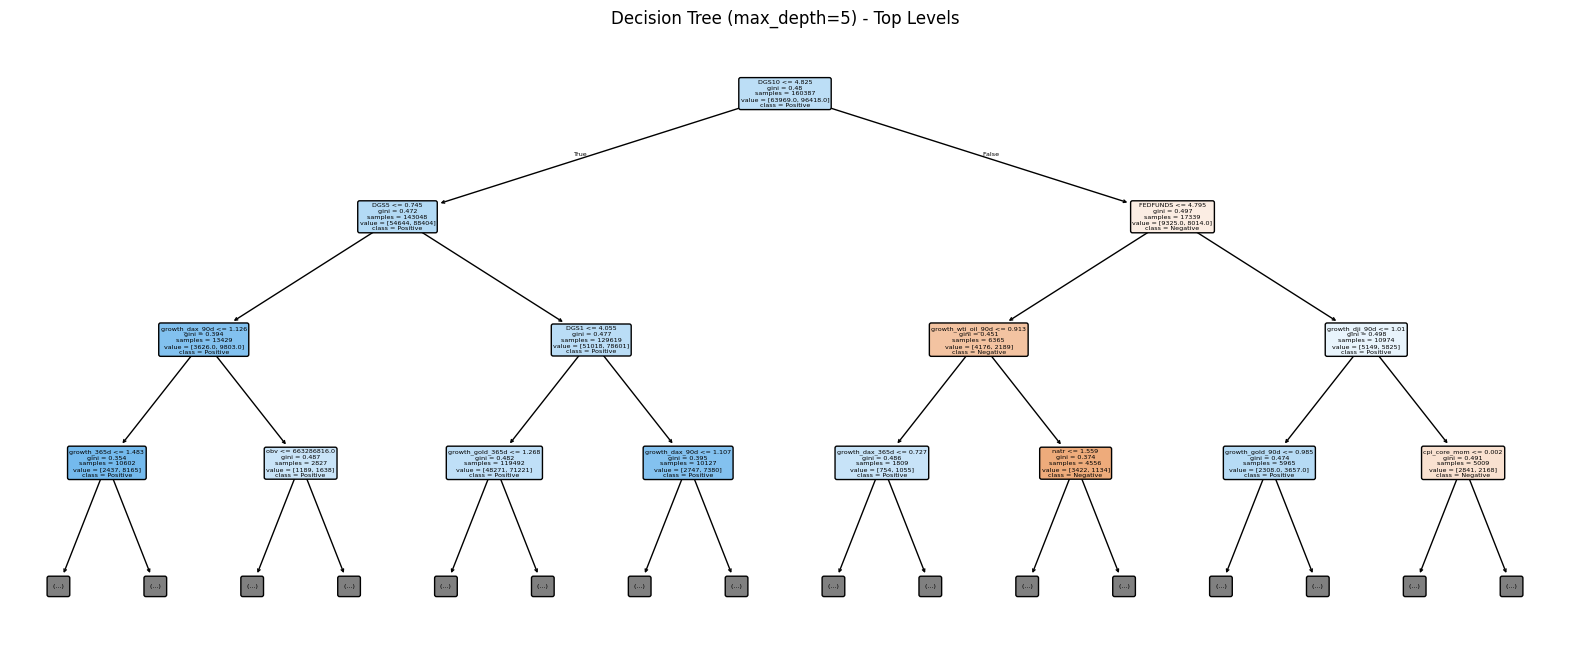

In [128]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Assuming you already have a dictionary of fitted models by depth
# e.g. clfs = {1: clf1, 2: clf2, ..., 20: clf20}
# If you only have one clf per iteration, you can also wrap this inside the fitting loop.

for m in range(1, 6):  # keep to small depths for readability
    clf = clfs[m]  # your stored classifiers, like {1: clf_1, 2: clf_2, ...}

    plt.figure(figsize=(20,8))
    plot_tree(
        clf,
        max_depth=3,   # show top 3 levels of the tree
        feature_names=train_columns,
        class_names=['Negative', 'Positive'],
        filled=True,
        rounded=True,
        impurity=True,  # show gini/entropy at nodes
        precision=3
    )
    plt.title(f"Decision Tree (max_depth={m}) - Top Levels")
    plt.show()

* Calculate the precision score on the TEST dataset for each fitted tree. You may also track precision on the VALIDATION dataset to observe signs of overfitting.

In [129]:
y_test = X_test_imputed[to_predict]

del X_test_imputed[to_predict]

1. Precision Score on test dataset

In [130]:
def predict_decision_tree(clf:DecisionTreeClassifier, df_X:pd.DataFrame, y_true: pd.Series):
  # Predict the target variable on the test data
  y_pred = clf.predict(df_X)

  max_depth = clf.tree_.max_depth
  # Print the maximum depth
  print("Maximum depth of the decision tree:", max_depth)

  # Calculate the accuracy/precision of the model
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  print(f'Accuracy ={accuracy}, precision = {precision}')

  # resulting df
  result_df = pd.concat([df_X, y_true, pd.Series(y_pred, index=df_X.index, name='pred_')], axis=1)

  return result_df

In [131]:
for m in range(1, 21):
  pred = predict_decision_tree(clfs[m], X_test_imputed.drop(['Date','Ticker'],axis=1), y_test)

Maximum depth of the decision tree: 1
Accuracy =0.5410404992358635, precision = 0.5465816507261778
Maximum depth of the decision tree: 2
Accuracy =0.5510697911360163, precision = 0.5510697911360163
Maximum depth of the decision tree: 3
Accuracy =0.5510697911360163, precision = 0.5510697911360163
Maximum depth of the decision tree: 4
Accuracy =0.5510697911360163, precision = 0.5510697911360163
Maximum depth of the decision tree: 5
Accuracy =0.5991467142129394, precision = 0.627845220030349
Maximum depth of the decision tree: 6
Accuracy =0.5498599083036169, precision = 0.5691415110800907
Maximum depth of the decision tree: 7
Accuracy =0.5701732042791645, precision = 0.5938485804416404
Maximum depth of the decision tree: 8
Accuracy =0.5762226184411615, precision = 0.5897136702270891
Maximum depth of the decision tree: 9
Accuracy =0.5642193071828834, precision = 0.5915457349446327
Maximum depth of the decision tree: 10
Accuracy =0.5571510443199185, precision = 0.5889278426037361
Maximum de

2. Identify the optimal max_depth where the precision score on the TEST dataset is highest. This value is your best_max_depth.

In [132]:
#precisions = []

#for m in range(1, 21):
#    pred_df = predict_decision_tree(clfs[m], X_test_imputed.drop(['Date','Ticker'],axis=1), y_test)
#    precision_m = precision_score(y_test, pred_df['pred_'])
#    precisions.append(precision_m)

#best_max_depth = np.argmax(precisions) + 1  # +1 because index starts at 0
#print(f'Best max_depth is {best_max_depth} with precision {precisions[best_max_depth-1]:.4f}')

In [133]:
precision = 0.6278
best_max_depth = 5

* Using best_max_depth, retrain the Decision Tree Classifier on the combined TRAIN+VALIDATION set

In [134]:
def fit_decision_tree(X, y, max_depth, random_state=42):
# Initialize the Decision Tree Classifier
  clf = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)

  # Fit the classifier to the training data
  clf.fit(X, y)
  return clf, X.columns

In [135]:
# using best_max_depth

%%time
clf_5, train_columns = fit_decision_tree(
    X=X_train_imputed.drop(['Date','Ticker'],axis=1),
    y=y_train,
    max_depth=5,
    random_state=42
)

CPU times: user 15.3 s, sys: 343 ms, total: 15.6 s
Wall time: 15.7 s


* Predict on the entire dataset (TRAIN + VALIDATION + TEST) and add the predictions as a new column ```pred6_clf_best``` in your dataframe new_df.

In [136]:
def predict_decision_tree(clf: DecisionTreeClassifier, df_X: pd.DataFrame, y_true: pd.Series):
    # Predict the target variable on the input data
    y_pred = clf.predict(df_X)

    max_depth = clf.tree_.max_depth
    print("Maximum depth of the decision tree:", max_depth)

    # Use y_true passed to the function
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    print(f'Accuracy = {accuracy}, precision = {precision}')

    # Combine features, true y, and predictions
    result_df = pd.concat([df_X, y_true, pd.Series(y_pred, index=df_X.index, name='pred_')], axis=1)

    return result_df

In [137]:
pred6 = predict_decision_tree(clf_10, X_all.drop(['Date','Ticker'],axis=1), y_all)

Maximum depth of the decision tree: 10
Accuracy = 0.6958314867436586, precision = 0.6950666328571831


In [138]:
# correct predictions to incorrect predictions
pred6.pred_.value_counts()

,count
pred_,
1,141972
0,49823


In [139]:
# rename pred column as pred6_clf_best
pred6_df = pred6[['pred_']].rename(columns={'pred_': 'pred6_clf_best'})
pred6_df.head(1)

,pred6_clf_best
0,0


In [140]:
# join to main dataframe new_df
newdf_pred6 = pred6_df.join(new_df)
newdf_pred6.sample(5)

,pred6_clf_best,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Ticker,Year,...,Month/WeekofMonth_September_w1,Month/WeekofMonth_September_w2,Month/WeekofMonth_September_w3,Month/WeekofMonth_September_w4,Month/WeekofMonth_September_w5,pred3_manual_dgs10_5,pred4_manual_dgs10_fedfunds,split,is_correct_pred3,is_correct_pred4
147880,1,13.700176,14.034327,13.407795,13.825482,662703.0,0.0,0.0,BHARTIARTL.NS,2002,...,0,0,0,0,0,False,True,train,1,0
117323,1,89.450989,90.223027,89.029882,90.117752,1720938.0,0.0,0.0,SIE.DE,2017,...,0,0,0,0,0,False,False,train,1,1
10357,1,25.479052,25.985259,25.281070,25.872768,200878000.0,0.0,0.0,AAPL,2015,...,0,0,0,1,0,False,False,train,0,0
21223,0,0.328034,0.336287,0.327347,0.334682,347724000.0,0.0,0.0,NVDA,2012,...,0,0,0,0,0,True,False,train,0,1
50841,0,227.960196,228.289202,222.078001,226.055969,16104000.0,0.0,0.0,AVGO,2025,...,0,0,0,0,0,False,True,test,1,0


* Compare the precision score of the tuned tree with previous predictions ```(pred0 to pred5)```. You should observe an improvement, ideally achieving precision > 0.58, indicating the tuned tree outperforms earlier models.

In [141]:
# Answer: Decision Tree Classifier 0.8518668328641831 > Hand Rule Prediciton 0.58

#### These parts of codes were not in the homework

In [144]:
newdf_pred6.keys()

Index(['pred6_clf_best', 'Open', 'High', 'Low', 'Close_x', 'Volume',
       'Dividends', 'Stock Splits', 'Ticker', 'Year',
       ...
       'Month/WeekofMonth_September_w1', 'Month/WeekofMonth_September_w2',
       'Month/WeekofMonth_September_w3', 'Month/WeekofMonth_September_w4',
       'Month/WeekofMonth_September_w5', 'pred3_manual_dgs10_5',
       'pred4_manual_dgs10_fedfunds', 'split', 'is_correct_pred3',
       'is_correct_pred4'],
      dtype='object', length=327)

In [190]:
# Make sure we have your NVDA TEST data first:
df_nvda_test = newdf_pred6[
    (newdf_pred6['Ticker'] == 'NVDA') &
    (newdf_pred6['split'] == 'test')
][['pred6_clf_best', 'Open', 'High', 'Low', 'Close_x', 'Year', 'Weekday', 'Month', 'WeekOfMonth', 'is_positive_growth_30d_future']]

In [195]:
#df_nvda_test

In [187]:
# Count how often the prediction and actual target were 1, grouped by year.
#df_nvda_test.groupby('Year').agg(
#    total_records = ('is_positive_growth_30d_future', 'count'),
#    predicted_positive = ('pred6_clf_best', 'sum'),
#    actual_positive = ('is_positive_growth_30d_future', 'sum'))